In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    'RAM_GB': [
        2, 3, 4, 4, 6, 6, 8, 8, 8, 12,
        12, 16, 4, 6, 8, 12, 16, 3, 4, 6,
        8, 12, 16, 4, 6, 8, 12, 16, 3, 6
    ],

    'Storage_GB': [
        32, 32, 64, 128, 128, 256, 128, 256, 512, 256,
        512, 512, 64, 128, 256, 256, 512, 32, 64, 128,
        256, 512, 512, 64, 128, 256, 256, 512, 32, 128
    ],

    'Battery_mAh': [
        3000, 4000, 4500, 5000, 4500, 5000, 4500, 5000, 5000, 5500,
        5000, 6000, 4000, 4500, 5000, 5000, 5500, 3500, 4500, 5000,
        5000, 5500, 6000, 4000, 4500, 5000, 5500, 6000, 3500, 5000
    ],

    'Screen_Size': [
        5.5, 6.0, 6.1, 6.4, 6.5, 6.6, 6.7, 6.7, 6.8, 6.8,
        6.9, 6.9, 6.1, 6.4, 6.6, 6.7, 6.8, 5.8, 6.2, 6.5,
        6.7, 6.8, 6.9, 6.0, 6.4, 6.6, 6.7, 6.8, 5.9, 6.5
    ],

    'Camera_MP': [
        8, 12, 12, 16, 24, 32, 48, 48, 64, 64,
        108, 200, 12, 16, 48, 64, 108, 8, 12, 24,
        48, 108, 200, 12, 24, 48, 64, 108, 8, 32
    ],

    'Weight_g': [
        160, 170, 175, 180, 185, 190, 195, 200, 205, 210,
        215, 220, 175, 180, 190, 200, 210, 165, 175, 185,
        195, 205, 215, 170, 180, 190, 200, 210, 165, 185
    ],

    'Price': [
        7999, 9999, 11999, 14999, 17999, 21999, 24999, 29999, 34999, 39999,
        49999, 69999, 13999, 16999, 23999, 32999, 59999, 8999, 12999, 18999,
        27999, 44999, 74999, 10999, 15999, 22999, 31999, 54999, 8499, 19999
    ]
}

df = pd.DataFrame(data)

df.head()

,RAM_GB,Storage_GB,Battery_mAh,Screen_Size,Camera_MP,Weight_g,Price
0,2,32,3000,5.5,8,160,7999
1,3,32,4000,6.0,12,170,9999
2,4,64,4500,6.1,12,175,11999
3,4,128,5000,6.4,16,180,14999
4,6,128,4500,6.5,24,185,17999


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RAM_GB       30 non-null     int64  
 1   Storage_GB   30 non-null     int64  
 2   Battery_mAh  30 non-null     int64  
 3   Screen_Size  30 non-null     float64
 4   Camera_MP    30 non-null     int64  
 5   Weight_g     30 non-null     int64  
 6   Price        30 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 1.8 KB


In [4]:
df.shape

(30, 7)

In [5]:
df.describe()

,RAM_GB,Storage_GB,Battery_mAh,Screen_Size,Camera_MP,Weight_g,Price
count,30.000000,30.000000,30.00000,30.000000,30.000000,30.000000,30.000000
mean,7.966667,230.400000,4800.00000,6.476667,52.666667,190.000000,27915.666667
std,4.358767,176.355753,738.12437,0.368298,51.376456,16.764083,18507.260147
min,2.000000,32.000000,3000.00000,5.500000,8.000000,160.000000,7999.000000
25%,4.000000,80.000000,4500.00000,6.250000,13.000000,176.250000,14249.000000
50%,7.000000,192.000000,5000.00000,6.600000,40.000000,190.000000,22499.000000
75%,12.000000,256.000000,5000.00000,6.775000,64.000000,203.750000,34499.000000
max,16.000000,512.000000,6000.00000,6.900000,200.000000,220.000000,74999.000000


In [6]:
df.isnull().sum()

,0
RAM_GB,0
Storage_GB,0
Battery_mAh,0
Screen_Size,0
Camera_MP,0
Weight_g,0
Price,0


In [7]:
X = df[
    [
        'RAM_GB',
        'Storage_GB',
        'Battery_mAh',
        'Screen_Size',
        'Camera_MP',
        'Weight_g'
    ]
]

In [8]:
y = df['Price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24, 6)
Testing data: (6, 6)


In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

LinearRegression()

In [13]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: 4507.17142906821

Coefficients:
RAM_GB : 1321.5777165569593
Storage_GB : 13.115341668978925
Battery_mAh : 0.23539448892600134
Screen_Size : -8019.432793557704
Camera_MP : 171.67942494814352
Weight_g : 272.4048450003061


In [14]:
y_pred = model.predict(X_test)

print(y_pred)

[54994.08911032 36638.85641955 11826.8221059   9523.00084539
 35270.15396622 38678.65883466]


In [15]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison

,Actual Price,Predicted Price
0,54999,54994.089110
1,32999,36638.856420
2,10999,11826.822106
3,8999,9523.000845
4,34999,35270.153966
5,39999,38678.658835


In [16]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1098.0142320124662


In [17]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 2670878.4105048636


In [18]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1634.2822309824162


In [19]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9897240971702281


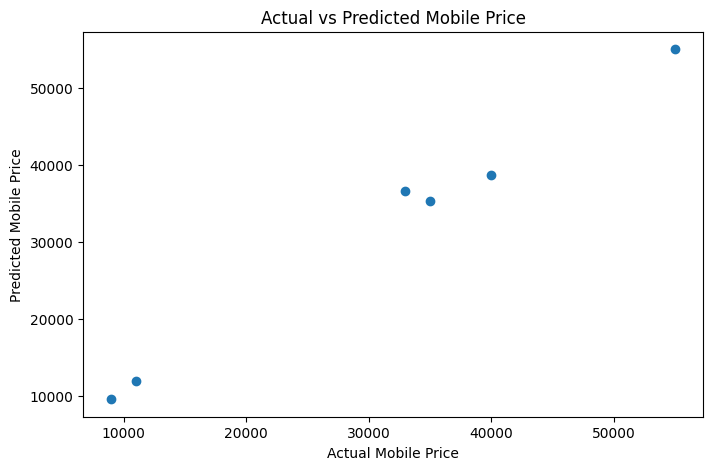

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Mobile Price")
plt.ylabel("Predicted Mobile Price")
plt.title("Actual vs Predicted Mobile Price")

plt.show()

In [21]:
new_mobile = [[
    8,      # RAM
    256,    # Storage
    5000,   # Battery
    6.7,    # Screen Size
    50,     # Camera
    195     # Weight
]]

predicted_price = model.predict(new_mobile)

print("Predicted Mobile Price: ₹", round(predicted_price[0], 2))

Predicted Mobile Price: ₹ 27587.01


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
ram = float(input("Enter RAM (GB): "))
storage = float(input("Enter Storage (GB): "))
battery = float(input("Enter Battery (mAh): "))
screen = float(input("Enter Screen Size (inches): "))
camera = float(input("Enter Camera (MP): "))
weight = float(input("Enter Weight (grams): "))

new_mobile = [[
    ram,
    storage,
    battery,
    screen,
    camera,
    weight
]]

predicted_price = model.predict(new_mobile)

print("\n📱 Predicted Mobile Price: ₹", round(predicted_price[0], 2))

Enter RAM (GB): 4
Enter Storage (GB): 128
Enter Battery (mAh): 5000
Enter Screen Size (inches): 16
Enter Camera (MP): 50
Enter Weight (grams): 600

📱 Predicted Mobile Price: ₹ 56365.17


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
# Convert the existing DataFrame into a CSV file
df.to_csv("mobile_price_prediction_dataset.csv", index=False)

# Download the CSV file
from google.colab import files
files.download("mobile_price_prediction_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>